# The AUROR_ref scene from a static pose — minimum viable

`AUROR_ref/` is a received DIRSIG run tree: a **static-pose detection scene**. A NIR sensor
hangs 550 km above a Lake Tahoe terrain tile (39° N, −120° E), looking straight down at an
embedded ~2 m vehicle target 50 km up. This notebook builds the dirfm job that reproduces the
tree's one surviving simulation, `jsims/AurorSimulation.jsim`, and runs it on this machine's
DIRSIG install. It renders one frame from one fixed geometry. There is no pass or orbit
propagation.

**Where the inputs live now (Stage 05).** `AUROR_ref/` itself has been retired. Its scene,
platform, weather and atmosphere database are read from their byte-identical copies in the
`config_repo/` library, and its motion and tasks files from `tests/fixtures/auror_ref/`. The job
built here is unchanged.

Nothing under those two folders is modified. The scene is referenced through the Tacoma notebook's
read-only pattern, every other input is a byte-identical copy, and both folders are fingerprinted
around the render. How the dirfm workarounds used here were found is recorded in
`notebooks/dev/auror_scene_buildup.ipynb` and FINDINGS.md ("2026-10-06 — Phase 5").

| Piece | From |
|---|---|
| Scene reference (XML copy + asset symlinks), input copies, fingerprint guard | `protodirsig.scene_ref` |
| Band coverage of the scene's real materials, including bundle materials | `protodirsig.scene_coverage` |
| `BasicPlatform` from existing `.platform`/`.ppd`/`.tasks` files; `SpiceEphemeris` with no inputs | `protodirsig.platform_ref` |
| `NewAtmosphere` over an existing database | `protodirsig.atmosphere_patches` |
| `ThermWeather` from a weather file | `dirfm.weather.ThermWeatherFilePlugin` |

| Stage | What it does |
|---|---|
| 0 | Reference the scene; check its materials cover the sensor band |
| 1 | Build the four plugins and assemble the job |
| 2 | Render, then look at the image and the geolocation truth |

---
# Stage 0 — The scene

## Environment

This uses the same convention as the other notebooks. `DIRSIG_HOME` comes from the environment,
with this machine's install as the fallback, and its `bin/` goes on `PATH`. `protodirsig` is
imported from `src/`.

In [1]:
import os
import shutil
import sys
from pathlib import Path

DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), "DIRSIG binaries not on PATH"

PROJECT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())   # repo root, from any depth
OUTPUTS = PROJECT / "outputs"
IN_DIR, OUT_DIR = OUTPUTS / "auror_tutorial_input", OUTPUTS / "auror_tutorial_output"

try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig

# AUROR_ref's files, where they live since Stage 05 (byte-identical copies): the engine assets
# in the config_repo library, the received motion and tasks in a test fixture. Both read-only.
CONFIG_REPO = PROJECT / "config_repo"
FIXTURE = PROJECT / "tests" / "fixtures" / "auror_ref"
SCENE_FILE = CONFIG_REPO / "scenes" / "tahoe" / "tahoe.scene"
print("DIRSIG_HOME :", DIRSIG_HOME)
print("scene       :", SCENE_FILE, "exists" if SCENE_FILE.is_file() else "MISSING")
print("motion/tasks:", FIXTURE, "exists" if FIXTURE.is_dir() else "MISSING")
assert SCENE_FILE.is_file() and FIXTURE.is_dir()

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
scene       : /home/kevin-kearney/dev/protoDIRSIG/config_repo/scenes/tahoe/tahoe.scene exists
motion/tasks: /home/kevin-kearney/dev/protoDIRSIG/tests/fixtures/auror_ref exists


## Referencing `tahoe.scene`

As in the Tacoma notebook, `scene_ref.reference_scene` copies only the `.scene` XML into the
job's directory, beside symlinks to its `geometry/`, `materials/` and `maps/` folders. Setting
dirfm's `SCENE._fname` to that copy makes `SCENE.write()` return the path untouched. The scene's
assets, including the vehicle bundle under `geometry/bundles/hypersonic/`, are read in place
through `$SCENE_DIR`, and `scene2hdf` writes its output next to the copy, not into `config_repo/`.

What the scene contains, from its XML:

* `features="vis,nir,swir,sources,exoatm"`;
* a terrain OBJ (`lists/terrain.glist`), all material 1, "Terrain (proxy)". The material and
  texture maps are disabled, as received;
* the vehicle (`lists/hypersonic.glist`): a bundle with its own material, `Gidder_mat`, a
  1500 K emitter with zero reflectance. It is placed by a `straight` dynamic instance starting
  at scene `(-400, 400, 50000)` m.

In [2]:
import lxml.etree as et
from dirfm import SCENE
from protodirsig.scene_ref import reference_scene

if IN_DIR.exists():
    shutil.rmtree(IN_DIR)                  # our own directory; rmtree unlinks symlinks, never follows them
REF_DIR = IN_DIR / "auror_ref"
ref_file = reference_scene(SCENE_FILE, REF_DIR)

auror_scene = SCENE("tahoe")
auror_scene._fname = ref_file                            # private attribute: write() returns it as-is

scene_xml = et.parse(str(ref_file)).getroot()
loc = scene_xml.find("sceneorigin/location")
LAT0, LON0, ALT0 = (float(loc.findtext(k)) for k in ("latitude", "longitude", "altitude"))
print(f"scene reference : {ref_file.relative_to(PROJECT)}")
print(f"scene origin    : {LAT0}, {LON0}, {ALT0} m; features {scene_xml.find('properties').get('features')!r}")
print(f"geometry lists  : {[g.text for g in scene_xml.iterfind('geometrylist/geometrylistinclude')]}")
print(f"maps            : {[(m.get('name'), m.get('enabled')) for m in scene_xml.find('maplist')]}")

Material [Dummy] ID has already been set to [N/A], can't override.


scene reference : outputs/auror_tutorial_input/auror_ref/tahoe.scene
scene origin    : 39.0, -120.0, 0.0 m; features 'vis,nir,swir,sources,exoatm'
geometry lists  : ['lists/terrain.glist', 'lists/hypersonic.glist']
maps            : [('Tahoe Class Map (small)', 'false'), ('Tahoe Texture Map (small)', 'false')]


## Band coverage

The sensor's bandpass is 0.41–2.0 µm (read from the platform file below). dirfm's own coverage
check can't see a `_fname` scene's materials, so `scene_coverage` reads them directly. It covers
the scene's `.mat` file and every bundle material reached through the geometry lists, which
here includes `Gidder_mat`.

In [3]:
from protodirsig.scene_coverage import scene_coverage

plat = et.parse(str(CONFIG_REPO / "platforms" / "AurorNIRDetector" / "AurorNIRDetector.platform")).getroot()
bp = plat.find(".//capturemethod/spectralresponse/bandpass")
BAND = (float(bp.findtext("minimum")), float(bp.findtext("maximum")))

cov = scene_coverage(ref_file)
for m in cov.materials:
    lo, hi = m.span
    print(f"  {m.id:>10s}  {m.name:22s} {lo:.2f}-{hi:.2f} um   ({m.source.name})")
print(f"sensor band {BAND[0]}-{BAND[1]} um covered by every material: {cov.covers(*BAND)}")
assert cov.covers(*BAND)

           1  Terrain (proxy)        0.20-20.00 um   (tahoe.mat)
          11  Water                  0.40-15.60 um   (tahoe.mat)
          12  Class #2               0.40-15.60 um   (tahoe.mat)
          13  Class #3               0.40-15.60 um   (tahoe.mat)
          14  Class #4 (asphalt)     0.40-15.60 um   (tahoe.mat)
          15  Class #5 (grass)       0.40-15.60 um   (tahoe.mat)
          16  Class #6 (coniferous)  0.40-15.60 um   (tahoe.mat)
          17  Class #7 (Pine Tree)   0.40-15.60 um   (tahoe.mat)
          18  Class #8               0.40-15.60 um   (tahoe.mat)
          19  Class #9 (concrete)    0.40-15.60 um   (tahoe.mat)
  Gidder_mat  Gidder_mat             0.40-3.00 um   (hypersonic.mat)
sensor band 0.41-2.0 um covered by every material: True


---
# Stage 1 — Plugins and assembly

The original jsim wires four plugins: `BasicPlatform`, `NewAtmosphere`, `SpiceEphemeris` and
`ThermWeather`. Each input file is copied into the job directory with `scene_ref.copy_input`,
asserted byte-identical, so the generated jsim holds relative paths into the job directory
instead of the original's Windows paths.

* **Platform, motion, tasks.** `platform_ref.PlatformFilesPlugin` emits `BasicPlatform` with the
  three files as given. The platform is "Auror NIR Detector": 500 × 500 pixels at 10 µm pitch,
  f = 306 mm, one Gaussian channel centred on 0.85 µm. The motion is a single pose: 550 km
  above scene `(-400, 400)`, looking straight down. The one task is a single frame at the
  reference time `2009-07-27T11:29:32-08:00`. That date is old, and uses PST for July, but it is
  what the tree specifies.
* **Atmosphere.** `atmosphere_patches.PatchedNewAtmospherePlugin` points at the existing
  database `AurorNewAtmosphere`, which sits beside the jsim as in the original. The backend block
  repeats the jsim's MODTRAN-tape settings. It is the recipe `atm_builder` would use to rebuild
  the database, and with an existing database it is carried for completeness.
* **Ephemeris.** `platform_ref.SpiceEphemerisPlugin`: `SpiceEphemeris` with no inputs, using
  DIRSIG's bundled kernels.
* **Weather.** `ThermWeatherFilePlugin` on `saw.wth`.

In [4]:
import json
from dirfm import DIRSIG
from dirfm.weather import ThermWeatherFilePlugin
from protodirsig.atmosphere_patches import PatchedModtranTapeBackend, PatchedNewAtmospherePlugin
from protodirsig.platform_ref import PlatformFilesPlugin, SpiceEphemerisPlugin
from protodirsig.scene_ref import copy_input

inputs = {name: copy_input(src, IN_DIR / dst) for name, src, dst in [
    ("platform", CONFIG_REPO / "platforms/AurorNIRDetector/AurorNIRDetector.platform", "platforms/AurorNIRDetector.platform"),
    ("motion", FIXTURE / "motion/AurorMotion.ppd", "motion/AurorMotion.ppd"),
    ("tasks", FIXTURE / "tasks/AurorTask.tasks", "tasks/AurorTask.tasks"),
    ("weather", CONFIG_REPO / "weather/saw.wth", "weather/saw.wth"),
    ("atmosphere", CONFIG_REPO / "atmosphere/AurorNewAtmosphere", "AurorNewAtmosphere")]}

# NB: the database was built for a site in western New York (43.12 N, -78.45 E), not Tahoe; the
# received run used it as-is, so this one does too.
atmosphere = (PatchedNewAtmospherePlugin(inputs["atmosphere"])
              .set_backend(PatchedModtranTapeBackend().set_profile("New Profile")
                           .set_atmospheric_model("MidLatitudeSummer")
                           .set_boundary_aerosol_model("RuralVis23Km")
                           .set_multiple_scattering("Isaac"))
              .set_info("", "", "", ""))

job = DIRSIG(IN_DIR, OUT_DIR)
job.add_plugin(PlatformFilesPlugin(inputs["platform"], inputs["motion"], inputs["tasks"]))
job.add_plugin(atmosphere)
job.add_plugin(SpiceEphemerisPlugin())
job.add_plugin(ThermWeatherFilePlugin(inputs["weather"]))
job.add_scene(auror_scene, [0, 0, 0])

jsim = job.write_files()                                 # builds the JSIM only; run() repeats this
jsim.write(IN_DIR / "preview.jsim")
print(json.dumps(json.loads((IN_DIR / "preview.jsim").read_text())[0], indent=1))

{
 "scene_list": [
  {
   "inputs": "auror_ref/tahoe.scene",
   "offset": "0,0,0"
  }
 ],
 "plugin_list": [
  {
   "name": "BasicPlatform",
   "inputs": {
    "platform_filename": "platforms/AurorNIRDetector.platform",
    "motion_filename": "motion/AurorMotion.ppd",
    "tasks_filename": "tasks/AurorTask.tasks",
    "split_channels": false
   }
  },
  {
   "name": "NewAtmosphere",
   "inputs": {
    "info": {
     "name": "",
     "author": "",
     "organization": "",
     "description": ""
    },
    "backend": {
     "name": "modtran_tape",
     "modtran_profile": "New Profile",
     "tape5_parameters": {
      "atmospheric_model": "MidLatitudeSummer",
      "multiple_scattering": {
       "type": "Isaac",
       "parameters": {}
      },
      "boundary_aerosol_model": {
       "type": "RuralVis23Km",
       "parameters": {}
      }
     }
    },
    "hdf_filename": "AurorNewAtmosphere"
   }
  },
  {
   "name": "SpiceEphemeris",
   "inputs": {}
  },
  {
   "name": "ThermWeather",


That is the original `AurorSimulation.jsim`, with its paths pointing into this job's
directory. dirfm also adds `offset: "0,0,0"` to the scene entry, which means no offset.

---
# Stage 2 — Render and inspect

`job.run()` compiles the scene with this install's `scene2hdf` into `auror_ref/` (no
pre-compiled `.hdf` is used), then renders with `dirsig5`. As in the Tacoma
notebook, `scene_ref.fingerprint` records every path under `config_repo/` and the fixture
before and after the run, and the cell asserts nothing changed. A render takes about 6 minutes on this machine.

In [5]:
import time
from protodirsig.scene_ref import fingerprint

assert not (REF_DIR / "tahoe.scene.hdf").exists()
before = fingerprint(CONFIG_REPO), fingerprint(FIXTURE)
t0 = time.perf_counter()
job.run()
elapsed = time.perf_counter() - t0
after = fingerprint(CONFIG_REPO), fingerprint(FIXTURE)

print(f"run() {elapsed:.0f} s")
print(f"config_repo + fixture fingerprint: {len(before[0]) + len(before[1])} paths, unchanged = {before == after}")
print(f"scene2hdf wrote       : {sorted(p.name for p in REF_DIR.iterdir() if not p.is_symlink())}")
print(f"outputs               : {sorted(p.name for p in OUT_DIR.iterdir())}")
assert before == after, "config_repo or the fixture changed during the run"
assert (REF_DIR / "tahoe.scene.hdf").is_file()

[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class1.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class2.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class3.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class4.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class5.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
[warn] ../../config_repo/scenes/tahoe/materials/emissivity/class6.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-

run() 224 s
config_repo + fixture fingerprint: 41 paths, unchanged = True
scene2hdf wrote       : ['asset_report.txt', 'tahoe.scene', 'tahoe.scene.hdf']
outputs               : ['AurorNIROutput.img', 'AurorNIROutput.img.hdr', 'truth1.img', 'truth1.img.hdr']


The `[warn]` lines are `dirsig5`'s, as expected for this scene. Materials 11–19 are unused because the material map is disabled. The terrain is 13 × 28 km, past the 10 km precision advisory. Curves that start at 0.40 µm fall short of DIRSIG's padded internal 0.35–2.55 µm grid, a margin outside the 0.85 µm channel's response.

## The image and the geolocation truth

The platform writes two ENVI files:

* `AurorNIROutput.img`: one band, the NIR channel, in `electrons/(m^2)`, the detector flux
  integrated over the 5 ms integration time;
* `truth1.img`: the `GeoLocation` truth collection. For each pixel it gives the geodetic
  latitude, longitude and WGS-84 altitude, and the ECEF position, of the surface the pixel's ray
  hit.

Below: the rendered frame, the terrain altitude from the truth, and the footprint on the ground.
The frame centre is where the sensor is pointed, and should sit under it at scene
`(-400, 400)`.

image  : (500, 500), electrons/(m^2), band ['NIR Detector'] at ['0.85'] um; acquisition 2009-07-27T11:29:32.0000-08:00
radiance range 6.229e+14 .. 1.996e+15, median 1.497e+15
frame centre hits scene ENU (-400.4, 400.2, 139.9) m; terrain in frame -9..1067 m
footprint 8.9 km E-W x 9.0 km N-S (~18 m pixels); misses 0


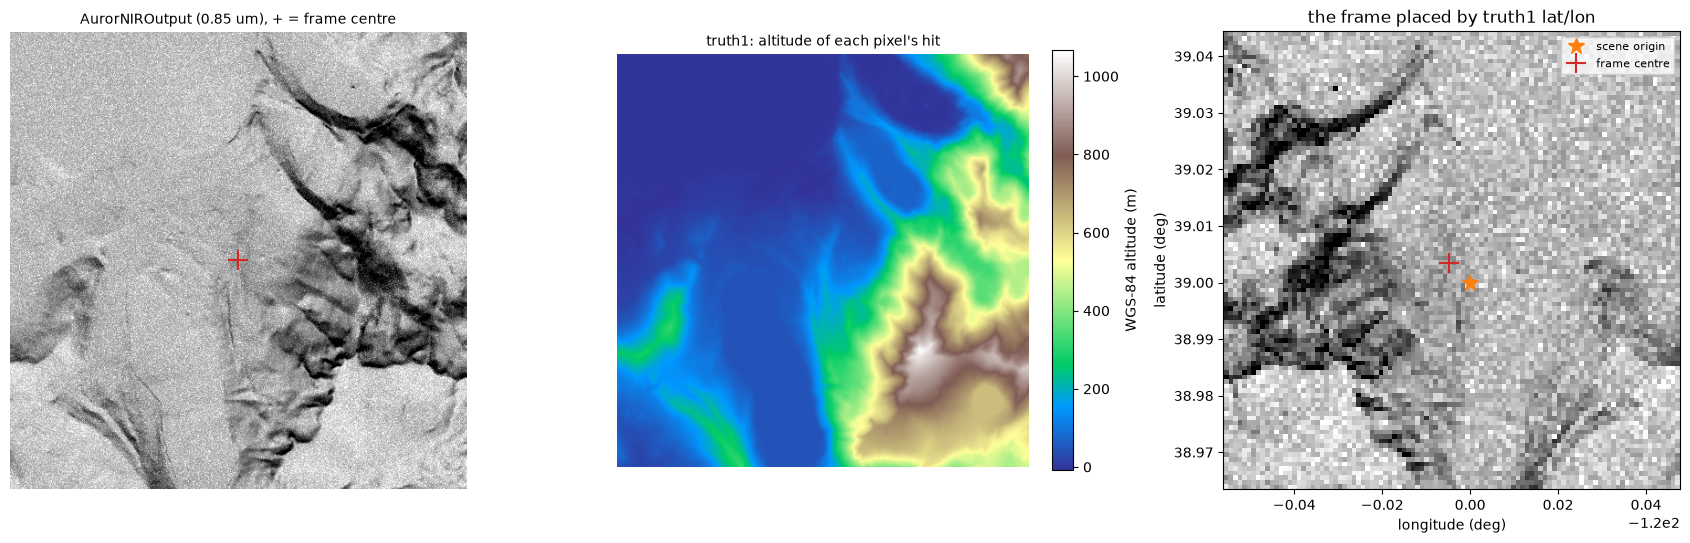

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from skyfield.api import wgs84
from spectral import open_image
from protodirsig import orbit

img = open_image(str(OUT_DIR / "AurorNIROutput.img.hdr"))
rad = np.asarray(img.load(), dtype=float)[:, :, 0]
tr = open_image(str(OUT_DIR / "truth1.img.hdr"))
truth = {n: np.asarray(tr.read_band(i), dtype=float) for i, n in enumerate(tr.metadata["band names"])}
lat, lon, alt = (truth[k] for k in ("Geodetic Latitude [degrees +N]", "Geodetic Longitude [degrees +E]", "WGS84 Altitude [m]"))
ecef = np.dstack([truth[f"ECEF {a} Coordinate [m]"] for a in "XYZ"])

print(f"image  : {rad.shape}, {img.metadata['data units']}, band {img.metadata['band names']} at "
      f"{img.metadata['wavelength']} um; acquisition {img.metadata['acquisition time']}")
print(f"radiance range {rad.min():.3e} .. {rad.max():.3e}, median {np.median(rad):.3e}")
c = rad.shape[0] // 2
e, n, u = orbit.ecef_to_enu_matrix(LAT0, LON0) @ (ecef[c - 1:c + 1, c - 1:c + 1].reshape(-1, 3).mean(0)
                                                  - wgs84.latlon(LAT0, LON0, elevation_m=ALT0).itrs_xyz.m)
print(f"frame centre hits scene ENU ({e:.1f}, {n:.1f}, {u:.1f}) m; terrain in frame {np.nanmin(alt):.0f}..{np.nanmax(alt):.0f} m")
km_n = (lat.max() - lat.min()) * 111.0
km_e = (lon.max() - lon.min()) * 111.0 * np.cos(np.radians(LAT0))
print(f"footprint {km_e:.1f} km E-W x {km_n:.1f} km N-S (~{km_e * 1e3 / rad.shape[1]:.0f} m pixels); misses {np.isnan(alt).sum()}")

fig, ax = plt.subplots(1, 3, figsize=(17, 5.4))
lo_, hi_ = np.percentile(rad, [1, 99])
ax[0].imshow(rad, cmap="gray", vmin=lo_, vmax=hi_)
ax[0].plot(c - 0.5, c - 0.5, "+", color="C3", ms=14, mew=1.5)
ax[0].set_title("AurorNIROutput (0.85 um), + = frame centre", fontsize=10); ax[0].axis("off")
m = ax[1].imshow(alt, cmap="terrain")
plt.colorbar(m, ax=ax[1], fraction=0.046, label="WGS-84 altitude (m)")
ax[1].set_title("truth1: altitude of each pixel's hit", fontsize=10); ax[1].axis("off")
ax[2].pcolormesh(lon[::5, ::5], lat[::5, ::5], rad[::5, ::5], cmap="gray", vmin=lo_, vmax=hi_, shading="auto")
ax[2].plot(LON0, LAT0, "*", color="C1", ms=12, label="scene origin")
ax[2].plot(lon[c, c], lat[c, c], "+", color="C3", ms=14, mew=1.5, label="frame centre")
ax[2].set(xlabel="longitude (deg)", ylabel="latitude (deg)", title="the frame placed by truth1 lat/lon")
ax[2].set_aspect(1 / np.cos(np.radians(LAT0))); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
assert np.hypot(e + 400, n - 400) < 18 and not np.isnan(alt).any()

**Reading the result.** The frame is the Tahoe terrain tile seen from straight above. All of it
is one grey material, so the contrast comes from relief: slope and shading. Fine pixel-to-pixel
grain is the renderer's Monte Carlo sampling noise. The truth image places every pixel on the
ground (no misses), with the frame centre directly under the sensor at scene `(-400, 400)`.
In the raw frame, row 0 is north but **column 0 is east**, so as rendered (pose yaw π, as
received) the image is mirror-imaged east to west compared with a map. The
third panel uses the truth latitude and longitude to place it correctly. (Checked from
`truth1`: longitude decreases from column 0 to column 499.)

**The vehicle target does not appear in this render.** The scene's 1500 K vehicle, 50 km up and
on the line of sight through the frame centre, is not visible there or anywhere else in the
frame. The image is bare terrain. The shipped 2025.51 render shows the same, so this belongs to
the received configuration, not this install. The investigation, and the candidate causes, are
in FINDINGS.md ("2026-10-06 — Phase 5").